## Final Project Submission

Please fill out:
* Student name: GROUP 2
* Student pace: full time
* Scheduled project review date/time: 
* Instructor name: Mrs MARYANNE MWIKALE
* Blog post URL:


In [2]:
# IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# DATA UNDERSTANDING

In [3]:
numbers = pd.read_csv(r"data/numbers.csv")
numbers

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
...,...,...,...,...,...,...
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0


In [4]:
box_office=pd.read_csv(r"data/box_office_mojo.csv")
box_office

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018


In [5]:
# Connect to the SQLite database
conn = sqlite3.connect(r'data/im.db')

cur=conn.cursor()

cur.execute("""SELECT name FROM sqlite_master WHERE type = 'table';""")
table_names = cur.fetchall()
table_names


[('movie_basics',),
 ('directors',),
 ('known_for',),
 ('movie_akas',),
 ('movie_ratings',),
 ('persons',),
 ('principals',),
 ('writers',)]

# UNDERSTANDING 'NUMBERS' DATA

In [6]:
numbers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB


The above information contains general information about the numbers dataset

In [7]:
numbers.describe()

,id
count,5782.000000
mean,50.372363
std,28.821076
min,1.000000
25%,25.000000
50%,50.000000
75%,75.000000
max,100.000000


The above information contains the statistical attributes of the numbers dataset

In [8]:
numbers.shape

(5782, 6)

The numbers dataset has 5782 rows and 6 columns

In [9]:
numbers.ndim

2

The numbers dataset has a total of 2 dimensions

In [10]:
numbers.columns

Index(['id', 'release_date', 'movie', 'production_budget', 'domestic_gross',
       'worldwide_gross'],
      dtype='object')

The numbers dataset has 6 columns in total

In [11]:
numbers.isna().sum()

id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64

The numbers dataset has 0 missing values in each column

In [12]:
numbers.duplicated().sum()

0

The numbers dataset has 0 duplcated values in each column

# UNDERSTANDING 'BOX OFFICE' DATASET

In [13]:
box_office.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


This is the general information about box office dataset

In [14]:
box_office.describe()

,domestic_gross,year
count,3.359000e+03,3387.000000
mean,2.874585e+07,2013.958075
std,6.698250e+07,2.478141
min,1.000000e+02,2010.000000
25%,1.200000e+05,2012.000000
50%,1.400000e+06,2014.000000
75%,2.790000e+07,2016.000000
max,9.367000e+08,2018.000000


This is the statistical information of the box office dataset

In [15]:
box_office.shape

(3387, 5)

The box office dataset contains 3387 rows and 5 columns

In [16]:
box_office.isna().sum()

title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

The box office dataset has missing values. The column with the highest missing values is the foreign_gross

In [17]:
box_office.duplicated().sum()  

0

The box office dataset has no duplicated values

# UNDERSTANDING 'IMDB' DATASET

In [18]:
cur.execute("""SELECT name FROM sqlite_master WHERE type = 'table';""")
table_names = cur.fetchall()
table_names

[('movie_basics',),
 ('directors',),
 ('known_for',),
 ('movie_akas',),
 ('movie_ratings',),
 ('persons',),
 ('principals',),
 ('writers',)]

Finding the tables in the IMDB dataset

In [19]:
imdb=pd.read_sql(""" SELECT movie_ratings.movie_id,genres,runtime_minutes,start_year,primary_title,
             movie_ratings.numvotes , movie_ratings.averagerating
             FROM movie_basics
            JOIN movie_ratings
            ON movie_basics.movie_id = movie_ratings.movie_id""",conn)

imdb

,movie_id,genres,runtime_minutes,start_year,primary_title,numvotes,averagerating
0,tt0063540,"Action,Crime,Drama",175.0,2013,Sunghursh,77,7.0
1,tt0066787,"Biography,Drama",114.0,2019,One Day Before the Rainy Season,43,7.2
2,tt0069049,Drama,122.0,2018,The Other Side of the Wind,4517,6.9
3,tt0069204,"Comedy,Drama",NaN,2018,Sabse Bada Sukh,13,6.1
4,tt0100275,"Comedy,Drama,Fantasy",80.0,2017,The Wandering Soap Opera,119,6.5
...,...,...,...,...,...,...,...
73851,tt9913084,Documentary,75.0,2019,Diabolik sono io,6,6.2
73852,tt9914286,"Drama,Family",98.0,2019,Sokagin Çocuklari,136,8.7
73853,tt9914642,Documentary,NaN,2017,Albatross,8,8.5
73854,tt9914942,None,NaN,2019,La vida sense la Sara Amat,5,6.6


Choosing the columns that will be used from the specified tables (movie_basics, movie_id)

In [20]:
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73856 entries, 0 to 73855
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         73856 non-null  object 
 1   genres           73052 non-null  object 
 2   runtime_minutes  66236 non-null  float64
 3   start_year       73856 non-null  int64  
 4   primary_title    73856 non-null  object 
 5   numvotes         73856 non-null  int64  
 6   averagerating    73856 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 3.9+ MB


This is the general information of the IMDB dataset

In [21]:
imdb.describe()

,runtime_minutes,start_year,numvotes,averagerating
count,66236.000000,73856.000000,7.385600e+04,73856.000000
mean,94.654040,2014.276132,3.523662e+03,6.332729
std,208.574111,2.614807,3.029402e+04,1.474978
min,3.000000,2010.000000,5.000000e+00,1.000000
25%,81.000000,2012.000000,1.400000e+01,5.500000
50%,91.000000,2014.000000,4.900000e+01,6.500000
75%,104.000000,2016.000000,2.820000e+02,7.400000
max,51420.000000,2019.000000,1.841066e+06,10.000000


This is the statistical data of the imdb dataset 

In [22]:
imdb.isna().sum()

movie_id              0
genres              804
runtime_minutes    7620
start_year            0
primary_title         0
numvotes              0
averagerating         0
dtype: int64

Every column in imdb dataset has no missing values except from genres and runtime_minutes with 804 and 7620 null values respectively

In [23]:
imdb.nunique()

movie_id           73856
genres               923
runtime_minutes      289
start_year            10
primary_title      69993
numvotes            7349
averagerating         91
dtype: int64

The above information contains number of uniques values in each column in the dataset

In [24]:
imdb.duplicated(['primary_title']).sum()

3863

This is the amount of duplicated values in the primary title.

In [25]:
imdb.duplicated(['movie_id']).sum()

0

There is no duplicated values in the movie_id column

In [26]:
#length of movie_id and length of primary_title should be same as they are unique identifiers
len(imdb['movie_id']) == len(imdb['primary_title'])

True

This means that each unique movie id is assigned to a specific primary title

# DATA CLEANING

In [27]:
# Dropping Columns
# Missing value
# Duplicate value
# Unique value
# Outlier detection
# Feature engineering

## Cleaning the numbers data

In [28]:
numbers.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [29]:
# Removing dollars sign from the numbers collection columns and converting them to numeric
numbers['production_budget'] = numbers['production_budget'].replace('[\$,]', '', regex=True).astype(float)
numbers['domestic_gross'] = numbers['domestic_gross'].replace('[\$,]', '', regex=True).astype(float)
numbers['worldwide_gross'] = numbers['worldwide_gross'].replace('[\$,]', '', regex=True).astype(float)
numbers.head()

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
C:\Users\user\AppData\Local\Temp\ipykernel_19512\2701295889.py:2: SyntaxWarning: invalid escape sequence '\$'
  numbers['production_budget'] = numbers['production_budget'].replace('[\$,]', '', regex=True).astype(float)
C:\Users\user\AppData\Local\Temp\ipykernel_19512\2701295889.py:3: SyntaxWarning: invalid escape sequence '\$'
  numbers['domestic_gross'] = numbers['domestic_gross'].replace('[\$,]', '', regex=True).astype(float)
C:\Users\user\AppData\Local\Temp\ipykernel_19512\2701295889.py:4: SyntaxWarning: invalid escape sequence '\$'
  numbers['worldwide_gross'] = numbers['worldwide_gross'].replace('[\$,]', '', regex=True).astype(float)


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,425000000.0,760507625.0,2.776345e+09
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09
2,3,"Jun 7, 2019",Dark Phoenix,350000000.0,42762350.0,1.497624e+08
3,4,"May 1, 2015",Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09


In [30]:
# Split date column into day, month, year
numbers['release_date'] = pd.to_datetime(numbers['release_date'], errors='coerce')
numbers['release_day'] = numbers['release_date'].dt.day
numbers['release_month'] = numbers['release_date'].dt.month
numbers['release_year'] = numbers['release_date'].dt.year
months = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}
numbers['months'] = numbers['release_month'].map(months)
numbers.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_day,release_month,release_year,months
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,18,12,2009,December
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,20,5,2011,May
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,7,6,2019,June
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1,5,2015,May
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,15,12,2017,December


In [31]:
numbers['net'] = ((numbers['worldwide_gross'] + numbers['domestic_gross']) - numbers['production_budget'])
numbers.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_day,release_month,release_year,months,net
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,18,12,2009,December,3.111853e+09
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,20,5,2011,May,8.761278e+08
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,7,6,2019,June,-1.574753e+08
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1,5,2015,May,1.531420e+09
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,15,12,2017,December,1.619903e+09


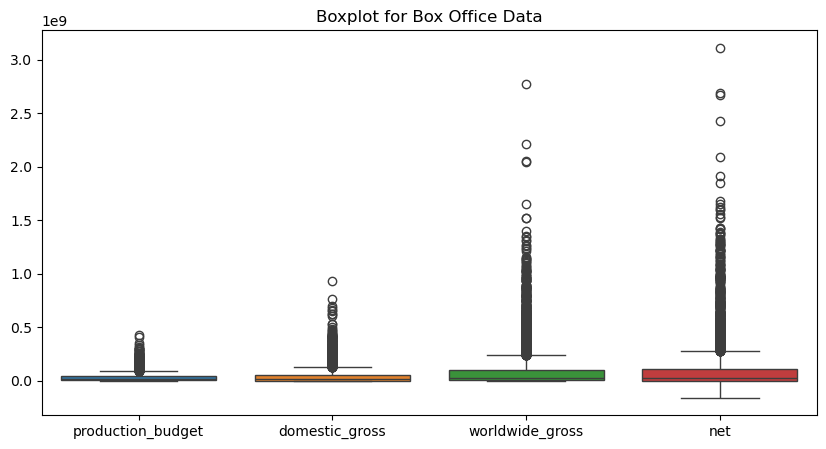

In [32]:
# Outlier detection using boxplots in numbers data
plt.figure(figsize=(10,5))
sns.boxplot(data=numbers[['production_budget', 'domestic_gross', 'worldwide_gross', 'net']])
plt.title('Boxplot for Box Office Data')
plt.show()

In [33]:
# numbers.to_csv('cleaned_numbers_data.csv', index=False)

## Cleaning box office data

In [34]:
# Box Office Mojo Data Cleaning
box_office.isna().sum()

title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

In [35]:
print(box_office['domestic_gross'].dtype)
d_gross_mean = int(box_office['domestic_gross'].mean())
d_gross_mean

float64


28745845

In [36]:
print(type(box_office['foreign_gross']))
# Finding the mean of foreign_gross column which is a pandas series
box_office['foreign_gross'] = pd.to_numeric(box_office['foreign_gross'], errors='coerce')
f_gross_mean = round(box_office['foreign_gross'].mean())
f_gross_mean

<class 'pandas.core.series.Series'>


75057042

In [37]:
# Filling missing values with mean
box_office['domestic_gross'].fillna(d_gross_mean, inplace=True)
box_office['foreign_gross'].fillna(f_gross_mean, inplace=True)


C:\Users\user\AppData\Local\Temp\ipykernel_19512\2687452425.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  box_office['domestic_gross'].fillna(d_gross_mean, inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_19512\2687452425.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

In [38]:
#Filling missing studio values with mode
studio_mode = box_office['studio'].mode()
print(studio_mode)
box_office['studio'].fillna(studio_mode[0], inplace=True)

0    IFC
Name: studio, dtype: object


C:\Users\user\AppData\Local\Temp\ipykernel_19512\2871670299.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  box_office['studio'].fillna(studio_mode[0], inplace=True)


In [39]:
box_office.isna().sum()

title             0
studio            0
domestic_gross    0
foreign_gross     0
year              0
dtype: int64

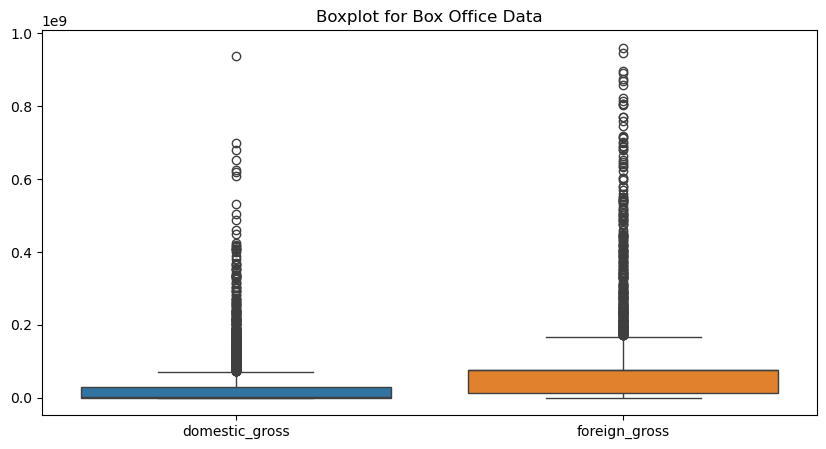

In [40]:
# Detecting outliers using boxplots in box_office data
plt.figure(figsize=(10,5))
sns.boxplot(data=box_office[['domestic_gross', 'foreign_gross']])
plt.title('Boxplot for Box Office Data')
plt.show()

In [41]:
# box_office.to_csv('cleaned_box_office_data.csv', index=False)

## Cleaning IMDB Data

In [42]:
imdb_df = pd.DataFrame(imdb)

In [43]:
imdb_genres_mode = imdb_df['genres'].mode()
print(imdb_genres_mode)

imdb_runtime_mean = round(imdb_df['runtime_minutes'].mean())
print(imdb_runtime_mean)

0    Drama
Name: genres, dtype: object
95


In [44]:
imdb_df['genres'] = imdb_df['genres'].fillna(imdb_genres_mode[0]).str.split(',').str[0]
imdb_df

,movie_id,genres,runtime_minutes,start_year,primary_title,numvotes,averagerating
0,tt0063540,Action,175.0,2013,Sunghursh,77,7.0
1,tt0066787,Biography,114.0,2019,One Day Before the Rainy Season,43,7.2
2,tt0069049,Drama,122.0,2018,The Other Side of the Wind,4517,6.9
3,tt0069204,Comedy,NaN,2018,Sabse Bada Sukh,13,6.1
4,tt0100275,Comedy,80.0,2017,The Wandering Soap Opera,119,6.5
...,...,...,...,...,...,...,...
73851,tt9913084,Documentary,75.0,2019,Diabolik sono io,6,6.2
73852,tt9914286,Drama,98.0,2019,Sokagin Çocuklari,136,8.7
73853,tt9914642,Documentary,NaN,2017,Albatross,8,8.5
73854,tt9914942,Drama,NaN,2019,La vida sense la Sara Amat,5,6.6


In [45]:
# Rate the rating with good, average and bad
imdb_df['rating_category'] = imdb_df['averagerating'].apply(lambda x: 'Good' if x > 7.0 else 'Average' if x > 4.0 else 'Bad')
imdb_df

,movie_id,genres,runtime_minutes,start_year,primary_title,numvotes,averagerating,rating_category
0,tt0063540,Action,175.0,2013,Sunghursh,77,7.0,Average
1,tt0066787,Biography,114.0,2019,One Day Before the Rainy Season,43,7.2,Good
2,tt0069049,Drama,122.0,2018,The Other Side of the Wind,4517,6.9,Average
3,tt0069204,Comedy,NaN,2018,Sabse Bada Sukh,13,6.1,Average
4,tt0100275,Comedy,80.0,2017,The Wandering Soap Opera,119,6.5,Average
...,...,...,...,...,...,...,...,...
73851,tt9913084,Documentary,75.0,2019,Diabolik sono io,6,6.2,Average
73852,tt9914286,Drama,98.0,2019,Sokagin Çocuklari,136,8.7,Good
73853,tt9914642,Documentary,NaN,2017,Albatross,8,8.5,Good
73854,tt9914942,Drama,NaN,2019,La vida sense la Sara Amat,5,6.6,Average


In [46]:
# Filling missing runtime values with mean
imdb_df['runtime_minutes'].fillna(imdb_runtime_mean, inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_19512\3047145700.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  imdb_df['runtime_minutes'].fillna(imdb_runtime_mean, inplace=True)


In [47]:
imdb_df.nunique()

movie_id           73856
genres                25
runtime_minutes      289
start_year            10
primary_title      69993
numvotes            7349
averagerating         91
rating_category        3
dtype: int64

In [48]:
imdb_df.isna().sum()

movie_id           0
genres             0
runtime_minutes    0
start_year         0
primary_title      0
numvotes           0
averagerating      0
rating_category    0
dtype: int64

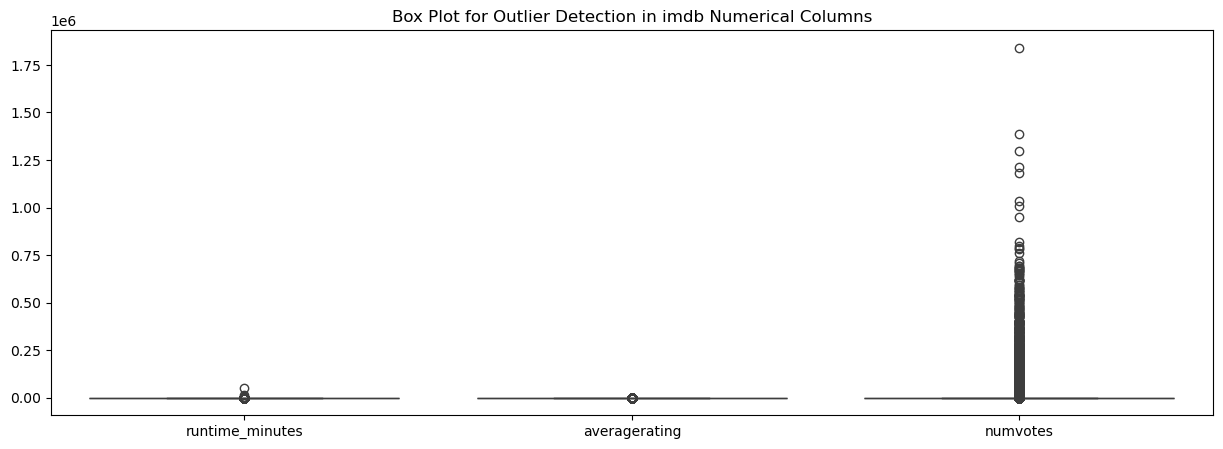

In [49]:
# Outlier Detection
figsize = (15, 5)
plt.figure(figsize=figsize)
sns.boxplot(data=imdb[['runtime_minutes', 'averagerating', 'numvotes']])
plt.title('Box Plot for Outlier Detection in imdb Numerical Columns')
plt.show()

In [50]:
# imdb_df.to_csv('cleaned_imdb_data.csv', index=False)

# Data analysis

In [51]:
#Loading cleaned data
c_numbers = pd.read_csv("cleaned_data/cleaned_numbers_data.csv")
c_box_office = pd.read_csv("cleaned_data/cleaned_box_office_data.csv")
c_imdb = pd.read_csv("cleaned_data/cleaned_imdb_data.csv")


## IMDB data analysis

### Univarient analysis

In [52]:
c_imdb.head()

,movie_id,genres,runtime_minutes,start_year,primary_title,numvotes,averagerating,rating_category
0,tt0063540,Action,175.0,2013,Sunghursh,77,7.0,Average
1,tt0066787,Biography,114.0,2019,One Day Before the Rainy Season,43,7.2,Good
2,tt0069049,Drama,122.0,2018,The Other Side of the Wind,4517,6.9,Average
3,tt0069204,Comedy,95.0,2018,Sabse Bada Sukh,13,6.1,Average
4,tt0100275,Comedy,80.0,2017,The Wandering Soap Opera,119,6.5,Average


In [53]:
# Find all mean of all numerical columns in c_imdb
c_imdb[['runtime_minutes', 'numvotes', 'averagerating']].mean()

runtime_minutes      94.689734
numvotes           3523.662167
averagerating         6.332729
dtype: float64

In [54]:
# Find all mode of all categorical columns in c_imdb
c_imdb[['genres', 'start_year', 'primary_title']].mode()

,genres,start_year,primary_title
0,Drama,2016,The Return


In [55]:
# Find all median of all numerical columns in c_imdb
c_imdb[['runtime_minutes', 'numvotes', 'averagerating']].median()

runtime_minutes    93.0
numvotes           49.0
averagerating       6.5
dtype: float64

In [56]:
# Find all standard deviations of all numerical columns in c_imdb
c_imdb[['runtime_minutes', 'averagerating', 'numvotes']].std()

runtime_minutes      197.521458
averagerating          1.474978
numvotes           30294.022971
dtype: float64

In [57]:
# Find variance of all numerical columns in c_imdb
c_imdb[['runtime_minutes', 'averagerating', 'numvotes']].var()

runtime_minutes    3.901473e+04
averagerating      2.175561e+00
numvotes           9.177278e+08
dtype: float64

In [58]:
# Find skewness of all numerical columns in c_imdb
c_imdb[['runtime_minutes', 'averagerating', 'numvotes']].skew()

runtime_minutes    242.72054
averagerating       -0.54802
numvotes            19.61896
dtype: float64

In [59]:
# Crosstab of genres start year and average rating in descending order
crosstab = pd.crosstab(index=c_imdb['genres'], columns=c_imdb['start_year'], values=c_imdb['averagerating'], aggfunc='mean').fillna(0)
crosstab = crosstab.sort_values(by=crosstab.columns.tolist(), ascending=False)
crosstab

start_year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
genres,,,,,,,,,,
Documentary,7.273131,7.265157,7.206263,7.213169,7.290370,7.335549,7.378506,7.375437,7.424448,7.563014
Biography,7.128205,7.242442,7.228451,7.130998,7.277939,7.185682,7.185028,7.042466,6.962009,7.355263
Sport,7.090909,7.530000,6.945455,6.014286,7.275000,5.387500,7.091667,7.346667,6.800000,7.850000
Music,7.068182,7.125000,7.644737,8.081818,7.593548,7.125000,7.650000,6.916667,7.890909,8.350000
Animation,6.602326,6.206195,6.196667,6.333333,6.335238,6.167857,6.314414,6.344643,5.933028,5.961290
History,6.342857,6.316667,6.513333,5.818182,6.236364,6.573333,6.536842,6.880000,6.560000,5.025000
Adventure,6.332857,6.334615,6.405000,6.422781,6.491223,6.345981,6.349675,6.282292,6.418987,6.710769
Drama,6.248711,6.280698,6.335343,6.273252,6.337757,6.242119,6.383925,6.530278,6.597548,6.872340
War,6.220000,6.550000,7.142857,5.400000,5.466667,5.900000,7.600000,3.900000,5.827273,5.266667


In [60]:
# Use for loop to find the highest rated genres for each year
highest_rated_genres_per_year = {}
for year in c_imdb['start_year'].unique():
    yearly_data = c_imdb[c_imdb['start_year'] == year]
    highest_rated_genre = yearly_data.groupby('genres')['averagerating'].mean().idxmax()
    highest_rating = yearly_data.groupby('genres')['averagerating'].mean().max()
    highest_rated_genres_per_year[year] = (highest_rated_genre, round(highest_rating, 2))
    # print(f"In {year}, the highest rated genre was '{highest_rated_genre}' with an average rating of {highest_rating:.2f}.")
highest_rated_genres_per_year

{2013: ('Game-Show', 9.0),
 2019: ('Music', 8.35),
 2018: ('Music', 7.89),
 2017: ('Documentary', 7.38),
 2010: ('Documentary', 7.27),
 2011: ('Sport', 7.53),
 2012: ('Music', 7.64),
 2015: ('Documentary', 7.34),
 2016: ('Music', 7.65),
 2014: ('Music', 7.59)}

### Bivarient analysis

In [61]:
# Calculate correlation coefficient
correlation_coefficient = c_imdb['runtime_minutes'].corr(c_imdb['averagerating'])
correlation_coefficient

-0.006509026999473114

In [62]:
# Coreelation matrix
correlation_matrix = c_imdb[['runtime_minutes', 'averagerating']].corr()
correlation_matrix

,runtime_minutes,averagerating
runtime_minutes,1.000000,-0.006509
averagerating,-0.006509,1.000000


In [63]:
# Covarience matrix
covariance_matrix = c_imdb[['runtime_minutes', 'averagerating']].cov()
covariance_matrix

,runtime_minutes,averagerating
runtime_minutes,39014.726359,-1.896339
averagerating,-1.896339,2.175561


## Numbers data analysis

In [64]:
# Add months column if not present
if 'months' not in c_numbers.columns:
    months = {
        1: 'January',
        2: 'February',
        3: 'March',
        4: 'April',
        5: 'May',
        6: 'June',
        7: 'July',
        8: 'August',
        9: 'September',
        10: 'October',
        11: 'November',
        12: 'December'
    }
    c_numbers['months'] = c_numbers['release_month'].map(months)

### Univarient analysis

In [65]:
c_numbers.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_day,release_month,release_year,months,net
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,18,12,2009,December,3.111853e+09
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,20,5,2011,May,8.761278e+08
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,7,6,2019,June,-1.574753e+08
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1,5,2015,May,1.531420e+09
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,15,12,2017,December,1.619903e+09


In [66]:
c_numbers[['production_budget', 'domestic_gross', 'worldwide_gross', 'net']].mean()

production_budget    3.158776e+07
domestic_gross       4.187333e+07
worldwide_gross      9.148746e+07
net                  1.017730e+08
dtype: float64

In [67]:
c_numbers[['production_budget', 'domestic_gross', 'worldwide_gross', 'net']].median()

production_budget    17000000.0
domestic_gross       17225945.0
worldwide_gross      27984448.5
net                  24995377.5
dtype: float64

In [68]:
c_numbers['months'].mode()

0    December
Name: months, dtype: object

In [69]:
c_numbers['months'].value_counts()

months
December     745
October      573
August       496
September    493
November     486
June         479
March        470
April        454
July         440
May          407
February     392
January      347
Name: count, dtype: int64

In [70]:
c_numbers[['production_budget', 'domestic_gross', 'worldwide_gross', 'net']].std()

production_budget    4.181208e+07
domestic_gross       6.824060e+07
worldwide_gross      1.747200e+08
net                  2.108880e+08
dtype: float64

In [71]:
c_numbers[['production_budget', 'domestic_gross', 'worldwide_gross', 'net']].var()

production_budget    1.748250e+15
domestic_gross       4.656779e+15
worldwide_gross      3.052707e+16
net                  4.447374e+16
dtype: float64

### Bivarient analysis

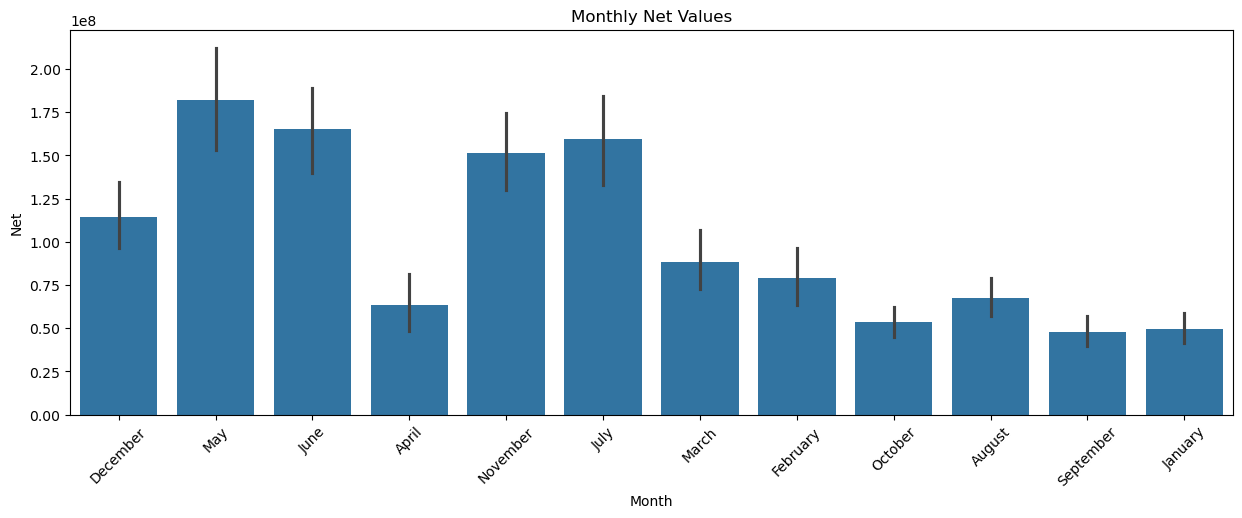

In [72]:
plt.figure(figsize=(15, 5))
sns.barplot(x='months', y='net', data=c_numbers)
plt.title("Monthly Net Values")
plt.xlabel("Month")
plt.ylabel("Net")
plt.xticks(rotation=45)
plt.show()

In [73]:
# Calculate correlation coefficient
correlation_coefficient1 = c_numbers['net'].corr(c_numbers['production_budget'])
print(f"budget coeff is {correlation_coefficient1}")

correlation_coefficient2 = c_numbers['net'].corr(c_numbers['release_month'])
print(f"release month cooff is {correlation_coefficient2}")


budget coeff is 0.6435798749669994
release month cooff is 0.029689234828224192


In [74]:
# Coreelation matrix
correlation_matrix = c_numbers[['production_budget', 'net', 'release_month']].corr()
correlation_matrix

,production_budget,net,release_month
production_budget,1.000000,0.643580,0.022575
net,0.643580,1.000000,0.029689
release_month,0.022575,0.029689,1.000000


In [75]:
# Covarience matrix
covariance_matrix = c_numbers[['production_budget', 'net', 'release_month']].cov()
covariance_matrix

,production_budget,net,release_month
production_budget,1.748250e+15,5.674871e+15,3.284974e+06
net,5.674871e+15,4.447374e+16,2.178956e+07
release_month,3.284974e+06,2.178956e+07,1.211143e+01


# Box office data analysis

### Univarient analysis

In [76]:
c_box_office.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000.0,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000.0,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000.0,2010
3,Inception,WB,292600000.0,535700000.0,2010
4,Shrek Forever After,P/DW,238700000.0,513900000.0,2010


In [77]:
c_box_office['studio'].value_counts()

studio
IFC           171
Uni.          147
WB            140
Fox           136
Magn.         136
             ... 
E1              1
PI              1
ELS             1
PalT            1
Synergetic      1
Name: count, Length: 257, dtype: int64

In [78]:
c_box_office[['domestic_gross', 'foreign_gross']].mean()

domestic_gross    2.874585e+07
foreign_gross     7.505704e+07
dtype: float64

In [79]:
c_box_office[['domestic_gross', 'foreign_gross']].median()

domestic_gross     1400000.0
foreign_gross     75057042.0
dtype: float64

In [80]:
c_box_office[['studio', 'year']].mode()

,studio,year
0,IFC,2015


In [81]:
c_box_office[['domestic_gross', 'foreign_gross']].std()

domestic_gross    6.670497e+07
foreign_gross     1.065140e+08
dtype: float64

In [82]:
c_box_office[['domestic_gross', 'foreign_gross']].var()

domestic_gross    4.449553e+15
foreign_gross     1.134524e+16
dtype: float64

### Bivarient analysis

In [83]:
# # Calculate correlation coefficient
correlation_coefficient1 = c_box_office['domestic_gross'].corr(c_box_office['foreign_gross'])
print(f"gross coeff is {correlation_coefficient1}")

gross coeff is 0.731948206104977


In [84]:
# Correlation matrix
c_box_office[['domestic_gross', 'foreign_gross']].corr()

,domestic_gross,foreign_gross
domestic_gross,1.000000,0.731948
foreign_gross,0.731948,1.000000


In [85]:
# Covariance matrix
c_box_office[['domestic_gross', 'foreign_gross']].cov()

,domestic_gross,foreign_gross
domestic_gross,4.449553e+15,5.200504e+15
foreign_gross,5.200504e+15,1.134524e+16


# DATA VISUALIZATIONS

In [86]:
c_numbers

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_day,release_month,release_year,months,net
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,18,12,2009,December,3.111853e+09
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,20,5,2011,May,8.761278e+08
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,7,6,2019,June,-1.574753e+08
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1,5,2015,May,1.531420e+09
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,15,12,2017,December,1.619903e+09
...,...,...,...,...,...,...,...,...,...,...,...
5777,78,2018-12-31,Red 11,7000.0,0.0,0.000000e+00,31,12,2018,December,-7.000000e+03
5778,79,1999-04-02,Following,6000.0,48482.0,2.404950e+05,2,4,1999,April,2.829770e+05
5779,80,2005-07-13,Return to the Land of Wonders,5000.0,1338.0,1.338000e+03,13,7,2005,July,-2.324000e+03
5780,81,2015-09-29,A Plague So Pleasant,1400.0,0.0,0.000000e+00,29,9,2015,September,-1.400000e+03


In [87]:
c_box_office

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000.0,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000.0,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000.0,2010
3,Inception,WB,292600000.0,535700000.0,2010
4,Shrek Forever After,P/DW,238700000.0,513900000.0,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,75057042.0,2018
3383,Edward II (2018 re-release),FM,4800.0,75057042.0,2018
3384,El Pacto,Sony,2500.0,75057042.0,2018
3385,The Swan,Synergetic,2400.0,75057042.0,2018


In [88]:
c_imdb

,movie_id,genres,runtime_minutes,start_year,primary_title,numvotes,averagerating,rating_category
0,tt0063540,Action,175.0,2013,Sunghursh,77,7.0,Average
1,tt0066787,Biography,114.0,2019,One Day Before the Rainy Season,43,7.2,Good
2,tt0069049,Drama,122.0,2018,The Other Side of the Wind,4517,6.9,Average
3,tt0069204,Comedy,95.0,2018,Sabse Bada Sukh,13,6.1,Average
4,tt0100275,Comedy,80.0,2017,The Wandering Soap Opera,119,6.5,Average
...,...,...,...,...,...,...,...,...
73851,tt9913084,Documentary,75.0,2019,Diabolik sono io,6,6.2,Average
73852,tt9914286,Drama,98.0,2019,Sokagin Çocuklari,136,8.7,Good
73853,tt9914642,Documentary,95.0,2017,Albatross,8,8.5,Good
73854,tt9914942,Drama,95.0,2019,La vida sense la Sara Amat,5,6.6,Average


In [ ]:
x=c_imdb["genres"].head(5)
y=c_imdb["averagerating"]

plt.bar(x,y)


<BarContainer object of 73856 artists>

Error in callback <function flush_figures at 0x0000019F94095F80> (for post_execute), with arguments args (),kwargs {}:
